In [2]:
import numpy as np
import matplotlib.pyplot as plt
import mglearn

plt.rcParams['font.sans-serif']=['Microsoft YaHei','SimHei','DejaVu Sans']
plt.rcParams['axes.unicode_minus']=False

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

cancer = load_breast_cancer()
X_train,X_test,y_train,y_test = train_test_split(
    cancer.data,cancer.target,stratify=cancer.target,random_state=42
)
print("="*50)
print("乳腺癌数据集")
print("="*50)
print(f"训练集:{X_train.shape[0]}个样本")
print(f"测试集:{X_test.shape[0]}个样本")
print(f"特征数:{X_train.shape[1]}")

乳腺癌数据集
训练集:426个样本
测试集:143个样本
特征数:30


In [6]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train,y_train)

print("="*50)
print("默认决策树(完全展开)")
print("="*50)
print(f"训练集精度:{tree.score(X_train,y_train):.3f}")
print(f"测试集精度:{tree.score(X_test,y_test):.3f}")

默认决策树(完全展开)
训练集精度:1.000
测试集精度:0.923


In [14]:
tree_limited=DecisionTreeClassifier(max_depth=4,random_state=42)
tree_limited.fit(X_train,y_train)

print("="*50)
print("限制深度(max_depth=4)")
print("="*50)
print(f"训练集精度:{tree_limited.score(X_train,y_train):.3f}")
print(f"测试集精度:{tree_limited.score(X_test,y_test):.3f}")

限制深度(max_depth=4)
训练集精度:0.988
测试集精度:0.944


In [17]:
from sklearn.tree import export_text

tree_text=export_text(tree_limited,feature_names=list(cancer.feature_names))
print(tree_text)

|--- worst radius <= 16.80
|   |--- worst concave points <= 0.14
|   |   |--- area error <= 91.56
|   |   |   |--- area error <= 48.70
|   |   |   |   |--- class: 1
|   |   |   |--- area error >  48.70
|   |   |   |   |--- class: 1
|   |   |--- area error >  91.56
|   |   |   |--- class: 0
|   |--- worst concave points >  0.14
|   |   |--- worst texture <= 25.62
|   |   |   |--- mean concave points <= 0.08
|   |   |   |   |--- class: 1
|   |   |   |--- mean concave points >  0.08
|   |   |   |   |--- class: 0
|   |   |--- worst texture >  25.62
|   |   |   |--- worst symmetry <= 0.27
|   |   |   |   |--- class: 1
|   |   |   |--- worst symmetry >  0.27
|   |   |   |   |--- class: 0
|--- worst radius >  16.80
|   |--- texture error <= 0.47
|   |   |--- class: 1
|   |--- texture error >  0.47
|   |   |--- worst concavity <= 0.19
|   |   |   |--- mean texture <= 21.35
|   |   |   |   |--- class: 1
|   |   |   |--- mean texture >  21.35
|   |   |   |   |--- class: 0
|   |   |--- worst conc

特征重要性排名
1. worst radius: 0.7268
2. worst concave points: 0.1221
3. texture error: 0.0484
4. worst texture: 0.0332
5. worst concavity: 0.0182
6. mean concave points: 0.0142
7. area error: 0.0126
8. mean texture: 0.0126
9. worst symmetry: 0.0119
10. mean fractal dimension: 0.0000


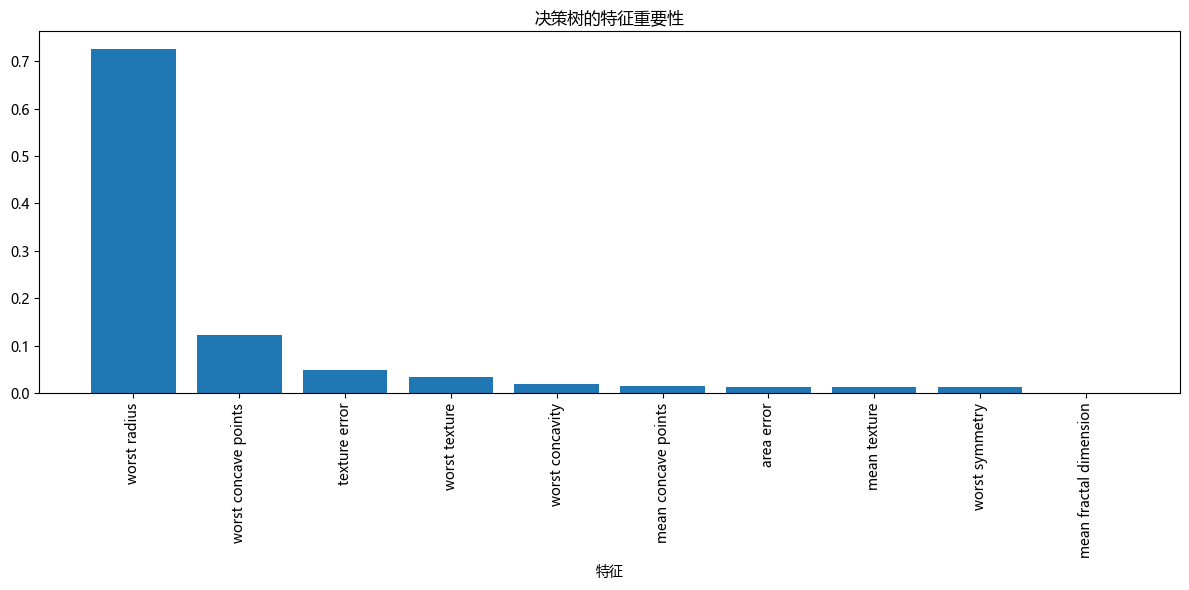

In [21]:
importances = tree_limited.feature_importances_

indices = np.argsort(importances)[::-1]

print("="*50)
print("特征重要性排名")
print("="*50)
for i in range(10):
    print(f"{i+1}. {cancer.feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

plt.figure(figsize=(12,6))
plt.bar(range(10),importances[indices[:10]])
plt.xticks(range(10),[cancer.feature_names[i] for i in indices[:10]],rotation=90)
plt.xlabel('特征')
plt.title('决策树的特征重要性')
plt.tight_layout()
plt.show()

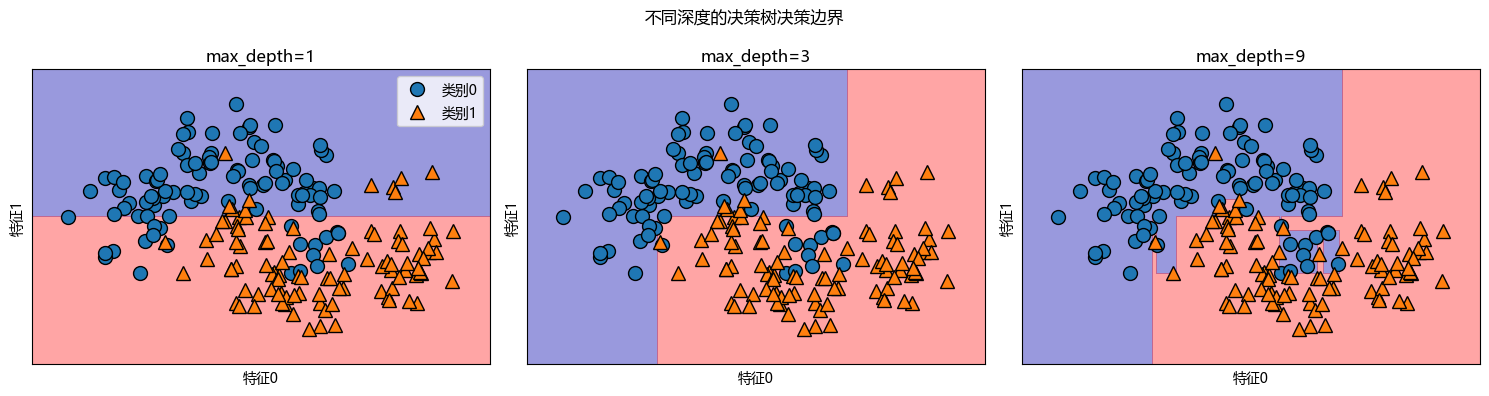

In [22]:
from sklearn.datasets import make_moons

X_moons,y_moons = make_moons(n_samples=200,noise=0.25,random_state=42)

fig,axes= plt.subplots(1,3,figsize=(15,4))

for depth,ax in zip([1,3,9],axes):
    tree = DecisionTreeClassifier(max_depth=depth,random_state=42)
    tree.fit(X_moons,y_moons)

    mglearn.plots.plot_2d_separator(tree,X_moons,fill=True,alpha=0.4,ax=ax)
    mglearn.discrete_scatter(X_moons[:,0],X_moons[:,1],y_moons,ax=ax)
    ax.set_title(f"max_depth={depth}")
    ax.set_xlabel("特征0")
    ax.set_ylabel("特征1")

axes[0].legend(["类别0","类别1"],loc="best")
plt.suptitle("不同深度的决策树决策边界")
plt.tight_layout()
plt.show()
